In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")
import cf_value as cfv

In [2]:
df = cfv.show_cf_val_results(folder='val_comp2')

26
27
28
29
66
67
68
69
76
77
78
79
91
92
93
94
236
237
238
239
261
262
263
264


                        slug  avg_percentile
0                   kprverse       82.514500
0         world-of-women-nft       80.298500
0              guttercatgang       79.730000
0          the-crypto-chicks       79.467000
0                  nakamigos       75.696500
0                sappy-seals       75.102500
0              beanzofficial       72.201000
0   sneaky-vampire-syndicate       69.191000
0          boredapeyachtclub       67.551500
0      mutant-ape-yacht-club       66.437000
0                     clonex       63.182500
0          coolmans-universe       59.334000
0              kanpai-pandas       58.157000
0              alienfrensnft       56.742500
0                   3landers       55.965500
0           doodles-official       55.414500
0               theshiboshis       54.380000
0                  hashmasks       54.229000
0                 veefriends       54.093500
0              cool-cats-nft       52.973000
0                 phantabear       51.352000
0         

<Axes: title={'center': 'Average Percentile by Slug'}, xlabel='slug'>

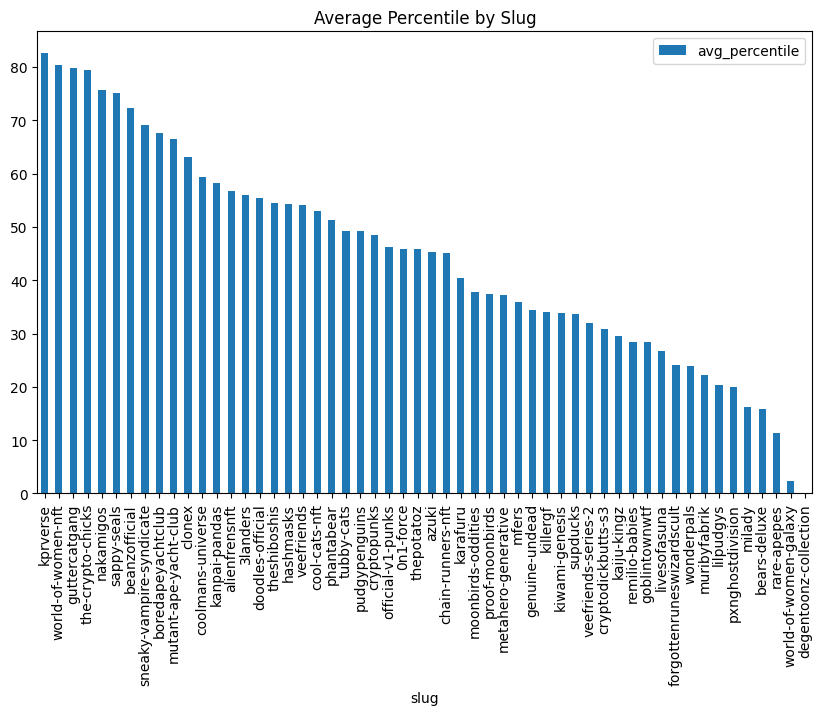

In [8]:
#compute average percentile for each slug
df = df.query("bandwidth != None")
df['avg_percentile'] = df.groupby('slug')['percentile'].transform('mean')
print(df[['slug', 'avg_percentile']].drop_duplicates().sort_values('avg_percentile', ascending=False))
#plot histogram of average percentiles
df[['slug', 'avg_percentile']].drop_duplicates().sort_values('avg_percentile', ascending=False).plot(
    kind='bar', x='slug', y='avg_percentile', title='Average Percentile by Slug', figsize=(10, 6))

In [4]:
df.bandwidth.unique()

array([25, 10, 5, 1, None], dtype=object)

In [5]:
import matplotlib.pyplot as plt
vis_df = df.query("bandwidth == 25 and interval_length == 1")

for _,row in vis_df.iterrows():
    knockoff_moves = row['data']
    control_moves = row['mean_samples']
    # plt.boxplot([knockoff_moves, control_moves], labels=['Release days','Other days'])
    # plt.ylabel('Price movement')
    # plt.show()
    # print(len(knockoff_moves), len(control_moves))
    if len(knockoff_moves) > 20:
        print(f"Slug: {row['slug']}, Knockoff moves: {len(knockoff_moves)}, Control moves: {len(control_moves)}")

Slug: 3landers, Knockoff moves: 38, Control moves: 10000
Slug: alienfrensnft, Knockoff moves: 26, Control moves: 10000
Slug: azuki, Knockoff moves: 94, Control moves: 10000
Slug: boredapeyachtclub, Knockoff moves: 84, Control moves: 10000
Slug: cool-cats-nft, Knockoff moves: 66, Control moves: 10000
Slug: cryptodickbutts-s3, Knockoff moves: 25, Control moves: 10000
Slug: cryptopunks, Knockoff moves: 54, Control moves: 10000
Slug: doodles-official, Knockoff moves: 82, Control moves: 10000
Slug: hashmasks, Knockoff moves: 120, Control moves: 10000
Slug: karafuru, Knockoff moves: 119, Control moves: 10000
Slug: killergf, Knockoff moves: 43, Control moves: 10000
Slug: kiwami-genesis, Knockoff moves: 106, Control moves: 10000
Slug: kprverse, Knockoff moves: 35, Control moves: 10000
Slug: metahero-generative, Knockoff moves: 35, Control moves: 10000
Slug: muribyfabrik, Knockoff moves: 75, Control moves: 10000
Slug: mutant-ape-yacht-club, Knockoff moves: 47, Control moves: 10000
Slug: nakamig

In [3]:
from scipy.stats import mannwhitneyu, brunnermunzel


#turn nones into 0s
df = df.fillna(0)
vis_df = df.query("bandwidth == 0 and interval_length == 1")
# vis_df = df
print(len(vis_df))
for _,row in vis_df.iterrows():

    knockoff_moves = row['data']
    control_moves = row['mean_samples']
    if len(knockoff_moves) > 30:
        stat, p_one = brunnermunzel(
            knockoff_moves,
            control_moves,
            alternative='less'   # tests distribution₁ shifted left of distribution₂
        )
        if p_one < 0.05:
            print(f"Slug: {row['slug']},interval: {row['interval_length']}, bandwidth:{row['bandwidth']}, Knockoff moves: {len(knockoff_moves)}, Control moves: {len(control_moves)}")
            print(f"U = {stat:.3f}, one‐sided p = {p_one:.3f}")


53
Slug: hashmasks,interval: 1, bandwidth:0, Knockoff moves: 120, Control moves: 10000
U = 7.367, one‐sided p = 0.000
Slug: kiwami-genesis,interval: 1, bandwidth:0, Knockoff moves: 106, Control moves: 10000
U = 3.478, one‐sided p = 0.000
Slug: muribyfabrik,interval: 1, bandwidth:0, Knockoff moves: 75, Control moves: 10000
U = 2.733, one‐sided p = 0.004
Slug: official-v1-punks,interval: 1, bandwidth:0, Knockoff moves: 45, Control moves: 10000
U = 2.204, one‐sided p = 0.016
Slug: remilio-babies,interval: 1, bandwidth:0, Knockoff moves: 32, Control moves: 10000
U = 2.046, one‐sided p = 0.025


In [2]:
import numpy as np

def bootstrap_diff(x, y, B=5000):
    diffs = []
    n, m = len(x), len(y)
    for _ in range(B):
        xs = np.random.choice(x, size=n, replace=True)
        ys = np.random.choice(y, size=m, replace=True)
        diffs.append(np.mean(xs) - np.mean(ys))
    return np.percentile(diffs, [2.5, 97.5])
vis_df = df.query("bandwidth == 0 and interval_length == 1")

for _,row in vis_df.iterrows():

    knockoff_moves = row['data']
    control_moves = row['mean_samples']
    if len(knockoff_moves) > 20:
        ci_low, ci_high = bootstrap_diff(knockoff_moves, control_moves)
        print(f"95% CI for μ_rel–μ_ctl: [{ci_low:.3f}, {ci_high:.3f}] for Slug: {row['slug']}, Knockoff moves: {len(knockoff_moves)}, Control moves: {len(control_moves)}")

NameError: name 'df' is not defined

In [38]:
import pandas as pd
import statsmodels.formula.api as smf

# assume your original df looks like:
#   collection   control_moves          ko_moves
# 0 "CoolCats"   [0.01, -0.02, …]       [-0.05, 0.03, …]
# 1 "BoredApe"   [ … ]                  [ … ]

# 1) explode control days
sub_df = df.query("bandwidth == 0 and interval_length == 1")
rows = []
rng = np.random.default_rng(42)
for _, row in sub_df.iterrows():
    coll = row['slug']
    ko = row['data']
    ctrl = row['mean_samples']
    if len(ko) <= 20:
        continue
    # how many KO observations?
    n_ko = len(ko)
    # if we have more controls than KOs, randomly pick n_ko of them
    if len(ctrl) > n_ko:
        ctrl_sample = rng.choice(ctrl, size=n_ko, replace=False).tolist()
    else:
        ctrl_sample = ctrl
    
    # add control rows
    for pm in ctrl_sample:
        rows.append({'collection': coll, 'price_move': pm, 'release': 0})
    # add KO rows
    for pm in ko:
        rows.append({'collection': coll, 'price_move': pm, 'release': 1})

df_sub = pd.DataFrame(rows)
model = smf.mixedlm("price_move ~ release", df_sub, groups="collection")
result = model.fit()
print(result.summary())


/global/scratch/tlundy/NFT_Research/nft_venv2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/global/scratch/tlundy/NFT_Research/nft_venv2/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/global/scratch/tlundy/NFT_Research/nft_venv2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/global/scratch/tlundy/NFT_Research/nft_venv2/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: price_move
No. Observations: 2696    Method:             REML      
No. Groups:       24      Scale:              7.1663    
Min. group size:  46      Log-Likelihood:     -6487.3091
Max. group size:  240     Converged:          No        
Mean group size:  112.3                                 
--------------------------------------------------------
                Coef. Std.Err.   z   P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept       0.065    0.084 0.779 0.436 -0.099  0.229
release         0.094    0.103 0.914 0.361 -0.108  0.296
collection Var  0.034    0.012                          



/global/scratch/tlundy/NFT_Research/nft_venv2/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/global/scratch/tlundy/NFT_Research/nft_venv2/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/global/scratch/tlundy/NFT_Research/nft_venv2/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 12.586521
  warnings.warn(msg, ConvergenceWarning)


In [25]:
import counterfeit_utils as cfu
top_slug = 'muribyfabrik'
df = cfu.day_sales_from_db(top_slug)

In [26]:
result = cfu.value_comparison_no_overlap(top_slug,1,db_name='objective_cf_num',logger=None)

No volume data for slug
No volume data for slug
No volume data for slug
No volume data for slug
No volume data for slug
No volume data for slug
Number of KO Days:  68
Number of Unique Values:  680


In [28]:
knockoff_moves = result[2]
control_moves = [x for x in result[1] if not np.isnan(x)]
if len(knockoff_moves) > 20:
    ci_low, ci_high = bootstrap_diff(knockoff_moves, control_moves)
    stat, p_one = brunnermunzel(
    knockoff_moves,
    control_moves,
    alternative='less'   # tests distribution₁ shifted left of distribution₂
)
    print(f"95% CI for μ_rel–μ_ctl: [{ci_low:.3f}, {ci_high:.3f}] for Slug: {row['slug']}, Knockoff moves: {len(knockoff_moves)}, Control moves: {len(control_moves)}")
    print(f"U = {stat:.3f}, one‐sided p = {p_one:.3f}")

95% CI for μ_rel–μ_ctl: [-0.021, 0.009] for Slug: world-of-women-nft, Knockoff moves: 49, Control moves: 427
U = 1.443, one‐sided p = 0.077


In [11]:
data[0]

TypeError: 'int' object is not subscriptable

/tmp/ipykernel_690386/3067447888.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  eth = yf.download("ETH-USD", start=start, end=end, progress=False)["Close"]


Found 3001 days where |ETH return| ≥ 10%
On big‐move days:  r = -0.528,  p = 4.06e-215


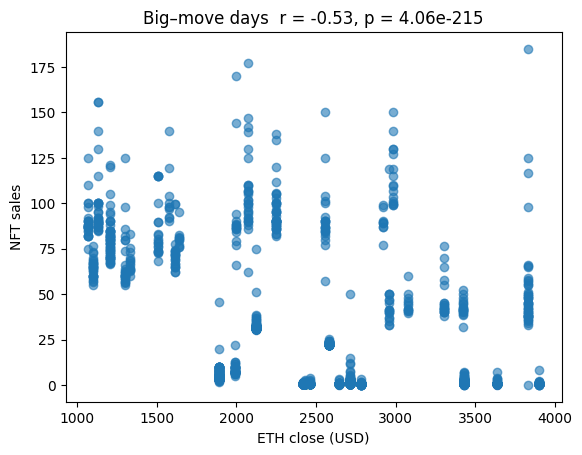

In [12]:
import pandas as pd
import yfinance as yf
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import counterfeit_utils as cfu

# 1. Load your NFT‐sales DataFrame
nft_df = cfu.day_sales_from_db("boredapeyachtclub")
nft_df["date"]  = pd.to_datetime(nft_df["day"])
nft_df.set_index("date", inplace=True)
nft_df["sales"] = nft_df["price"]

# 2. Download ETH–USD daily closes
start = nft_df.index.min().strftime("%Y-%m-%d")
end   = (nft_df.index.max() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
eth = yf.download("ETH-USD", start=start, end=end, progress=False)["Close"]



eth = eth.sort_index().asfreq("D", method="ffill")      # fill weekends/holidays
eth_ret = eth.pct_change()                               # (today – yesterday) / yesterday

# 2. Align returns to your NFT dates
nft_df["eth_close"] = eth.reindex(nft_df.index)         # from previous step
nft_df["eth_ret"]   = eth_ret.reindex(nft_df.index)

# 3. Filter to “big‐move” days (|return| ≥ 10%)
big_move = nft_df[nft_df["eth_ret"].abs() >= 0.10]

print(f"Found {len(big_move)} days where |ETH return| ≥ 10%")

# 4. Recompute correlation on that subset
from scipy.stats import pearsonr
r, pval = pearsonr(big_move["sales"], big_move["eth_close"])
print(f"On big‐move days:  r = {r:.3f},  p = {pval:.3g}")

# 5. (Optional) Scatter only big moves
import matplotlib.pyplot as plt
plt.scatter(big_move["eth_close"], big_move["sales"], alpha=0.6)
plt.xlabel("ETH close (USD)")
plt.ylabel("NFT sales")
plt.title(f"Big–move days  r = {r:.2f}, p = {pval:.3g}")
plt.show()

In [35]:
import pandas as pd
import yfinance as yf
from scipy.stats import mannwhitneyu,brunnermunzel
import matplotlib.pyplot as plt
import counterfeit_utils as cfu

for slug in cfu.get_top_slugs(cut_off=5, db_name="objective_cf_num"):
    raw = cfu.day_sales_from_db(slug)
    raw["date"] = pd.to_datetime(raw["day"])
    daily = (
        raw.groupby("date")["price"]
        .mean()
        .to_frame("sales")
        .sort_index()
    )
    daily["nft_change"] = daily["sales"].diff()

    # 2. Fetch ETH closes and compute pct returns
    start = daily.index.min().strftime("%Y-%m-%d")
    end   = (daily.index.max() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    eth = (
        yf.download("ETH-USD", start=start, end=end, progress=False)["Close"]
        .sort_index()
        .asfreq("D", method="ffill")
    )
    eth_ret = eth.pct_change()

    # 3. Align and shift ETH returns
    daily["eth_ret_prev"] = eth_ret.reindex(daily.index).shift(1)

    # 4. Drop NaNs
    df = daily.dropna(subset=["nft_change", "eth_ret_prev"])

    # 5. Split by whether yesterday’s ETH move was ≥10%
    big   = df[df["eth_ret_prev"].abs() >= 0.1]["nft_change"]
    small = df[df["eth_ret_prev"].abs() <  0.1]["nft_change"]

    # 6. Mann–Whitney U test
    U, pval = brunnermunzel(big, small, alternative="two-sided")
    print(f"U = {U:.2f}, p = {pval:.3g}")

# # 7. (Optional) Visualization
# plt.boxplot([small, big], labels=["|ETH₋₁|<10%", "|ETH₋₁|≥10%"])
# plt.ylabel("NFT sales change (USD)")
# plt.title(f"Mann–Whitney p = {pval:.3g}")
# plt.tight_layout()
# plt.show()

/tmp/ipykernel_690386/1419871328.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf.download("ETH-USD", start=start, end=end, progress=False)["Close"]


U = 0.00, p = 0.997


KeyboardInterrupt: 

In [25]:
import counterfeit_utils as cfu
slug = 'pudgypenguins'
values = cfu.value_comparison_no_overlap(slug,15,db_name='objective_cf_num',logger=None,no_overlap=True,only_tops=True)

['0n1-force', '3landers', 'alienfrensnft', 'azuki', 'beanzofficial', 'bears-deluxe', 'boredapeyachtclub', 'chain-runners-nft', 'clonex', 'cool-cats-nft', 'coolmans-universe', 'cryptodickbutts-s3', 'cryptopunks', 'degentoonz-collection', 'doodles-official', 'forgottenruneswizardscult', 'genuine-undead', 'goblintownwtf', 'guttercatgang', 'hashmasks', 'kaiju-kingz', 'kanpai-pandas', 'karafuru', 'killergf', 'kiwami-genesis', 'kprverse', 'lilpudgys', 'livesofasuna', 'metahero-generative', 'mfers', 'milady', 'moonbirds-oddities', 'muribyfabrik', 'mutant-ape-yacht-club', 'nakamigos', 'official-v1-punks', 'phantabear', 'proof-moonbirds', 'pudgypenguins', 'pxnghostdivision', 'rare-apepes', 'remilio-babies', 'sappy-seals', 'sneaky-vampire-syndicate', 'supducks', 'the-crypto-chicks', 'thepotatoz', 'theshiboshis', 'tubby-cats', 'veefriends', 'veefriends-series-2', 'wonderpals', 'world-of-women-galaxy', 'world-of-women-nft']
No volume data for slug
Number of KO Days:  22
Number of no ko days:  627


In [26]:
import numpy as np
from scipy.stats import mannwhitneyu,brunnermunzel

knockoff_moves = values[2]
control_moves = [x for x in values[1] if not np.isnan(x)]
if len(knockoff_moves) > 2:
    ci_low, ci_high = bootstrap_diff(knockoff_moves, control_moves)
    stat, p_one = brunnermunzel(
    knockoff_moves,
    control_moves,
    alternative='less'   # tests distribution₁ shifted left of distribution₂
)
    print(f"95% CI for μ_rel–μ_ctl: [{ci_low:.3f}, {ci_high:.3f}] for Slug: {slug}, Knockoff moves: {len(knockoff_moves)}, Control moves: {len(control_moves)}")
    print(f"U = {stat:.3f}, one‐sided p = {p_one:.3f}")

95% CI for μ_rel–μ_ctl: [-0.544, 0.019] for Slug: pudgypenguins, Knockoff moves: 15, Control moves: 627
U = 1.684, one‐sided p = 0.057


Comparing 0n1-force and neotokyopunkscollabs
Pearson r = -0.066 (p = 0.631)
Spearman ρ = 0.256 (p = 0.0569)


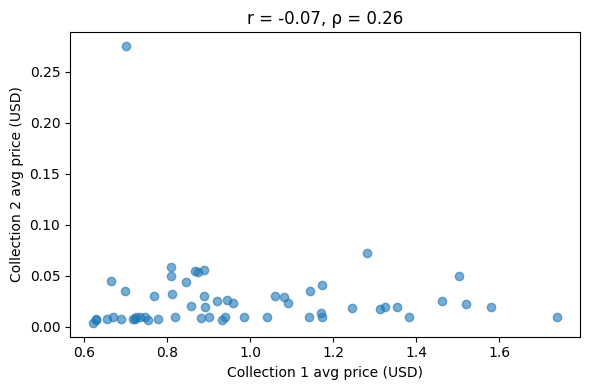

Comparing 0n1-force and vainego
Pearson r = -0.401 (p = 0.325)
Spearman ρ = -0.143 (p = 0.736)


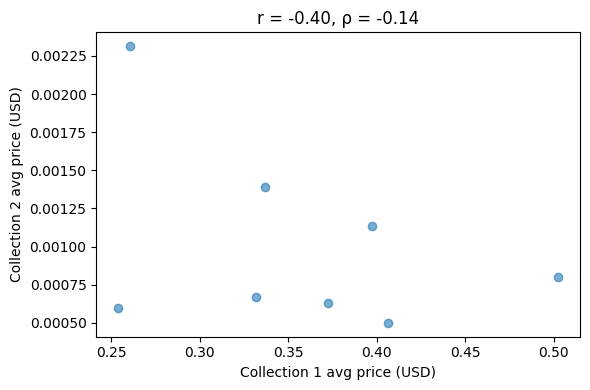

Comparing 0n1-force and mekazuki
Pearson r = 0.184 (p = 0.0927)
Spearman ρ = 0.186 (p = 0.0887)


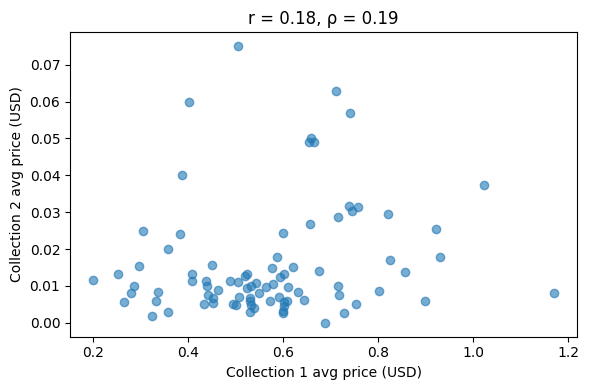

Comparing 0n1-force and roars-by-ntp
Pearson r = 0.060 (p = 0.369)
Spearman ρ = 0.234 (p = 0.000381)


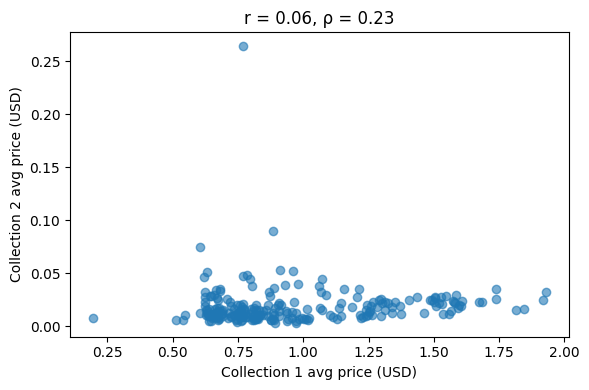

Comparing 0n1-force and tokyo-brave-heroes
Pearson r = -0.324 (p = 1.47e-08)
Spearman ρ = -0.356 (p = 3.65e-10)


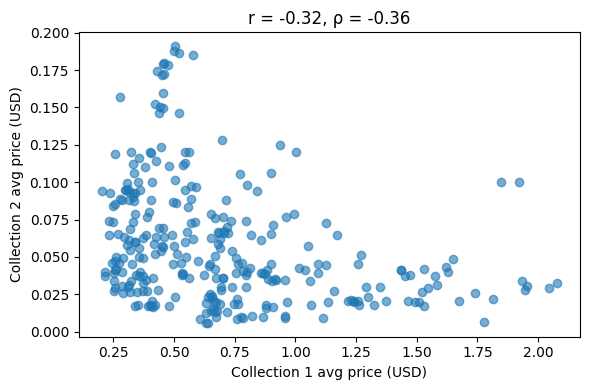

Comparing 0n1-force and skullzuki
Pearson r = 0.495 (p = 3.04e-06)
Spearman ρ = 0.521 (p = 7.46e-07)


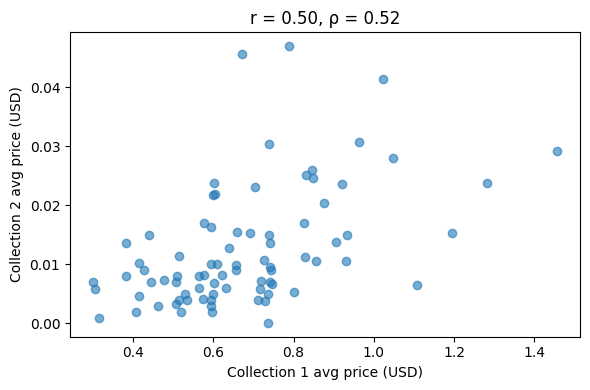

Comparing 0n1-force and dreamzukinft
Pearson r = 0.201 (p = 0.0116)
Spearman ρ = 0.193 (p = 0.0152)


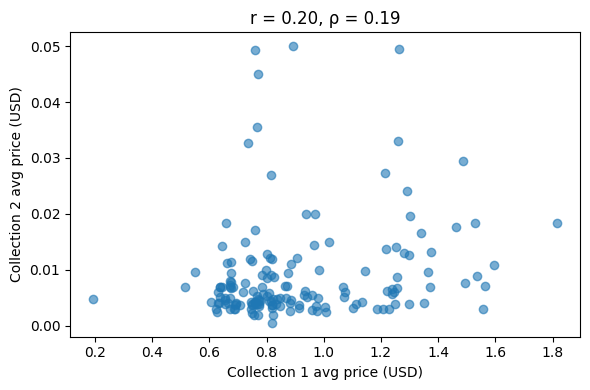

Comparing 0n1-force and tokyobraveheroes2g
Pearson r = -0.020 (p = 0.841)
Spearman ρ = 0.098 (p = 0.336)


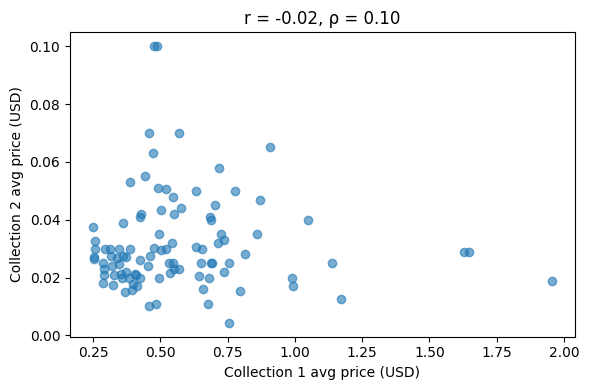

Comparing 0n1-force and 0xvampire-project
Pearson r = 0.779 (p = 1.73e-70)
Spearman ρ = 0.422 (p = 4.39e-16)


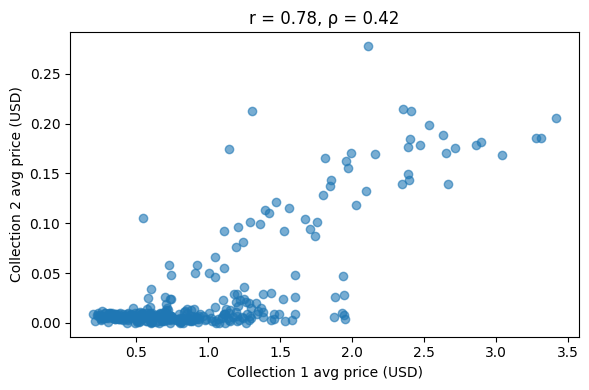

Comparing 0n1-force and ssa-international
Pearson r = -0.077 (p = 0.497)
Spearman ρ = -0.171 (p = 0.13)


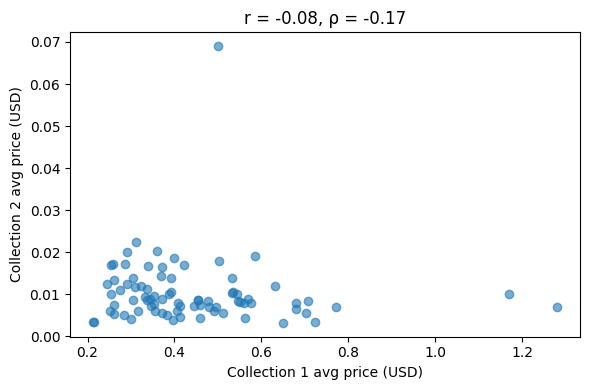

Comparing 0n1-force and ryokoclub
Pearson r = -0.315 (p = 0.0333)
Spearman ρ = -0.445 (p = 0.00196)


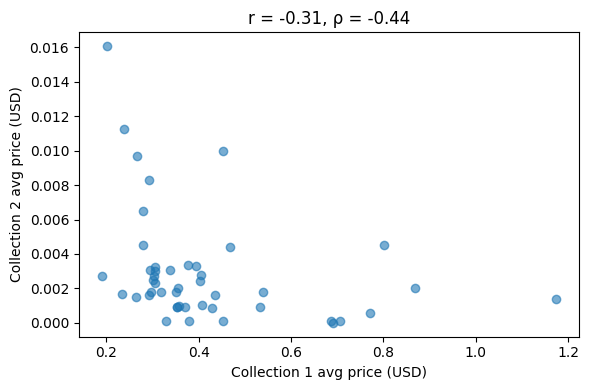

Comparing 0n1-force and skull-elementals
Pearson r = -0.387 (p = 0.391)
Spearman ρ = -0.342 (p = 0.452)


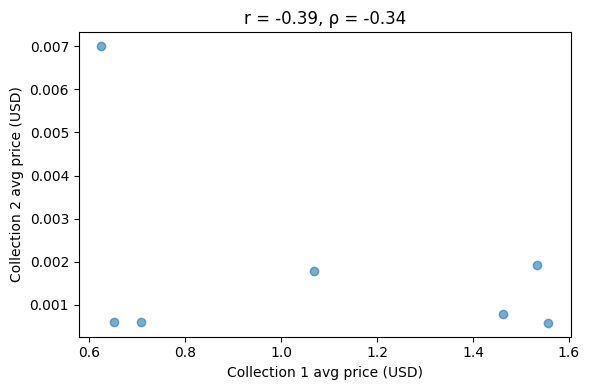

Comparing 0n1-force and 0xzuki
Pearson r = 0.158 (p = 0.0176)
Spearman ρ = 0.210 (p = 0.00152)


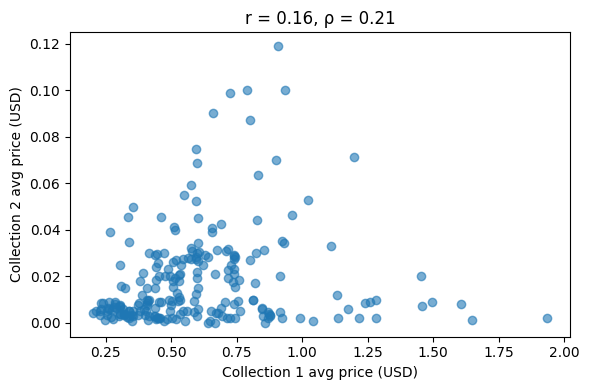

Comparing 0n1-force and 0xhunter
Pearson r = 0.468 (p = 3.79e-05)
Spearman ρ = 0.571 (p = 1.99e-07)


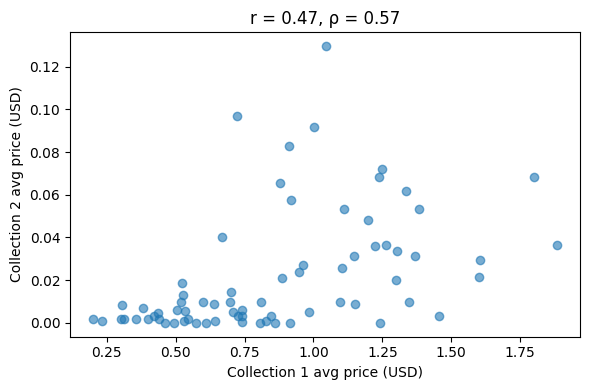

Comparing 3landers and frnds-club
Pearson r = -0.178 (p = 0.0672)
Spearman ρ = -0.411 (p = 1.23e-05)


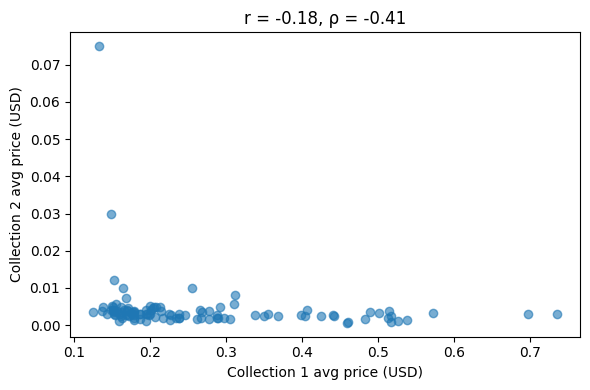

Comparing 3landers and the-pepe-chimpsons
Pearson r = -0.124 (p = 0.486)
Spearman ρ = 0.174 (p = 0.325)


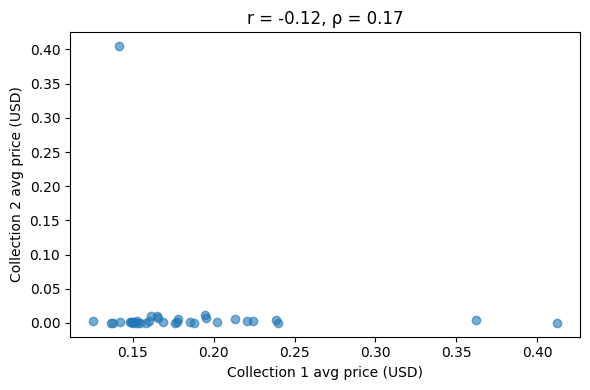

Comparing 3landers and toonsquad-official
Pearson r = 0.464 (p = 1.74e-15)
Spearman ρ = 0.763 (p = 1.2e-51)


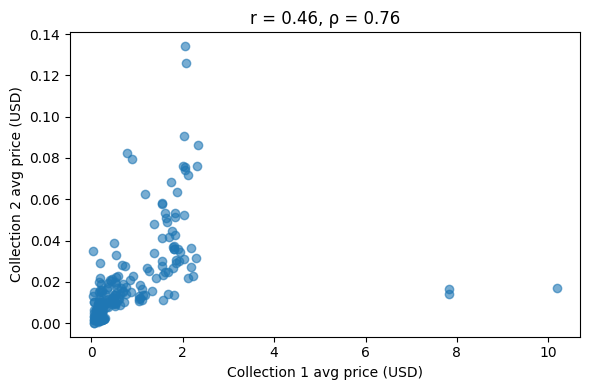

Comparing 3landers and the-chimpsons-official
Pearson r = 0.319 (p = 6.87e-07)
Spearman ρ = 0.555 (p = 3.94e-20)


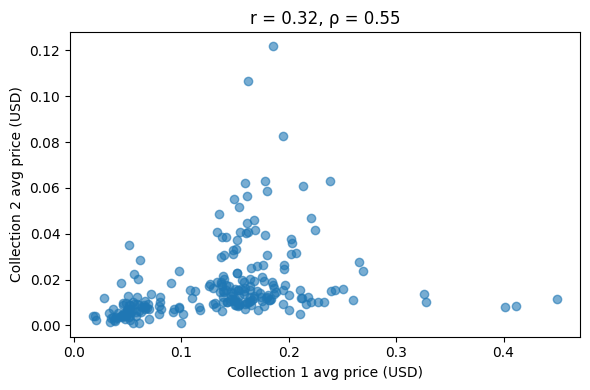

Comparing 3landers and we-the-kids
Pearson r = 0.308 (p = 0.072)
Spearman ρ = 0.497 (p = 0.00239)


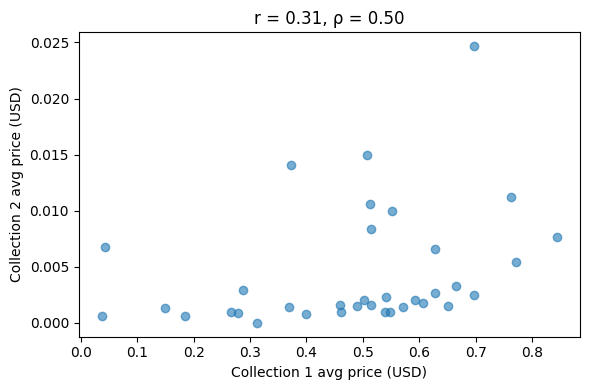

Comparing 3landers and colorful-ape-club-official
Pearson r = 0.461 (p = 0.000128)
Spearman ρ = 0.513 (p = 1.49e-05)


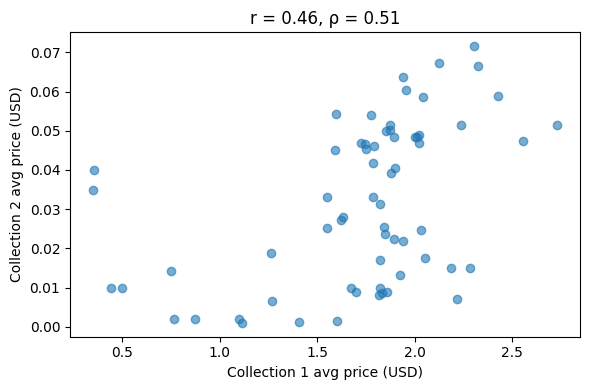

Comparing 3landers and pastel-cronies
Pearson r = 0.608 (p = 0.0624)
Spearman ρ = 0.583 (p = 0.077)


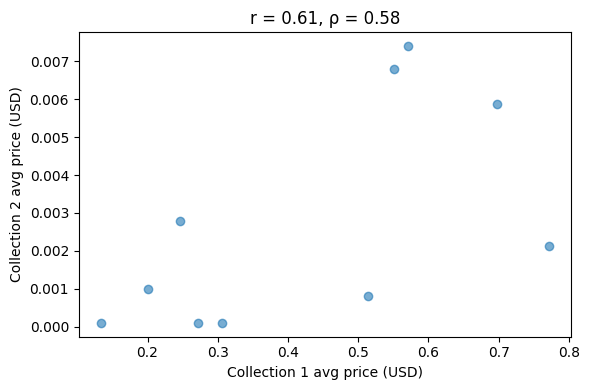

Comparing 3landers and theapefrens
Pearson r = 0.007 (p = 0.956)
Spearman ρ = 0.325 (p = 0.0129)


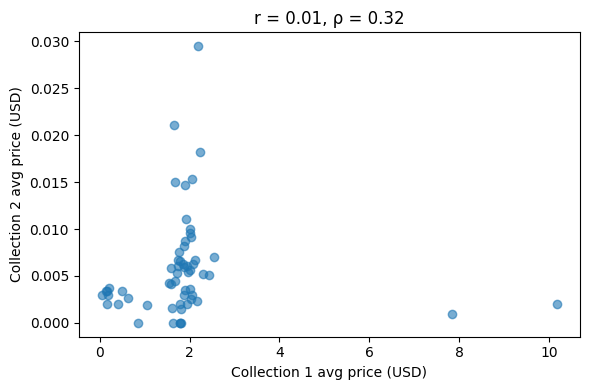

Comparing 3landers and voiceverse-genesis
Pearson r = 0.297 (p = 1.91e-09)
Spearman ρ = 0.814 (p = 1.4e-94)


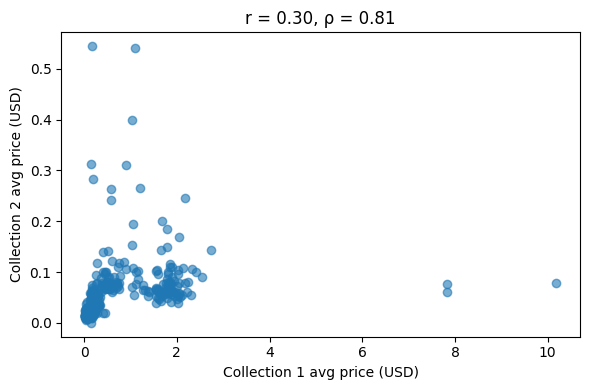

Comparing 3landers and apemaniasocialclub
Pearson r = 0.362 (p = 0.481)
Spearman ρ = 0.030 (p = 0.954)


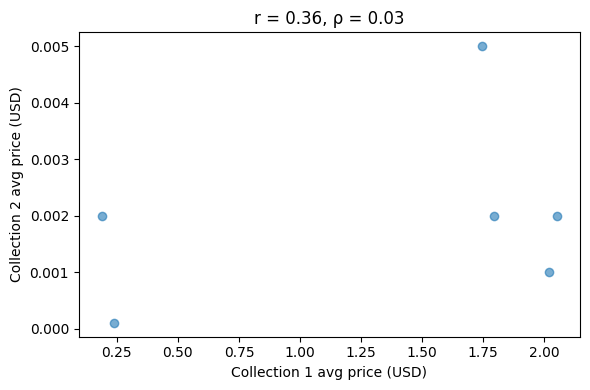

Comparing 3landers and mobs-and-aliens
Pearson r = 0.178 (p = 0.146)
Spearman ρ = 0.360 (p = 0.00256)


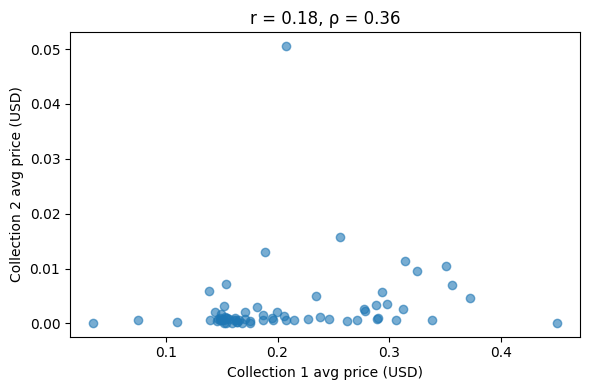

Comparing 3landers and theapesonsclub
Pearson r = -0.442 (p = 0.273)
Spearman ρ = -0.571 (p = 0.139)


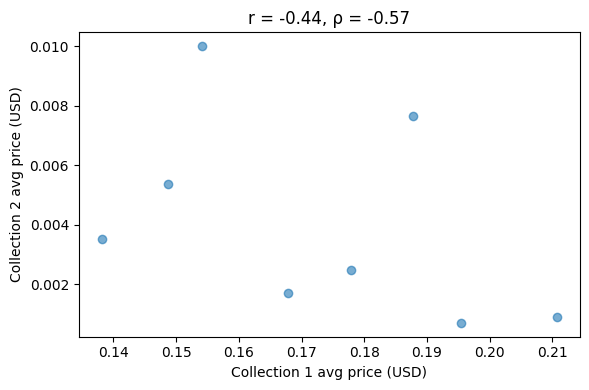

Comparing 3landers and sodativity
Pearson r = 0.007 (p = 0.9)
Spearman ρ = 0.756 (p = 1.24e-55)


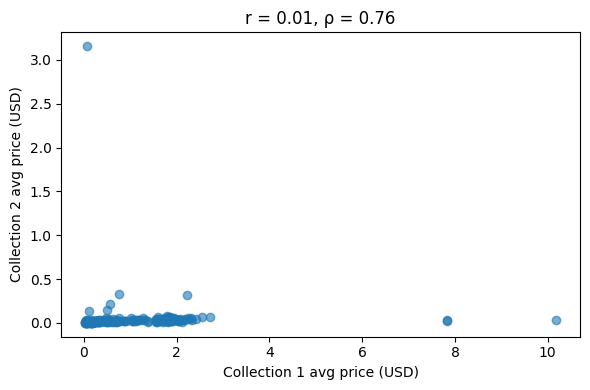

Comparing 3landers and gemapeclubnft
Pearson r = -0.444 (p = 0.000694)
Spearman ρ = -0.249 (p = 0.0667)


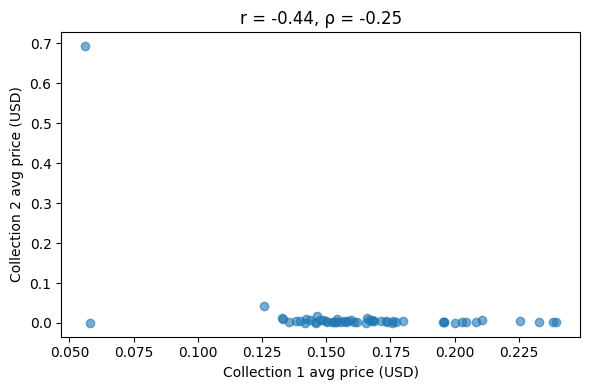

Comparing 3landers and zoodlers
Pearson r = 0.390 (p = 0.0728)
Spearman ρ = 0.442 (p = 0.0396)


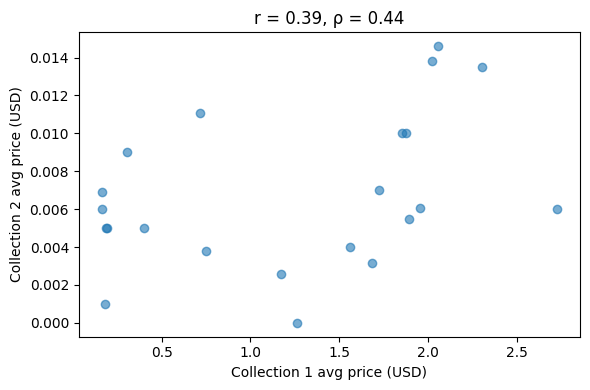

Comparing 3landers and internetfrens
Pearson r = 0.138 (p = 0.0594)
Spearman ρ = 0.504 (p = 1.98e-13)


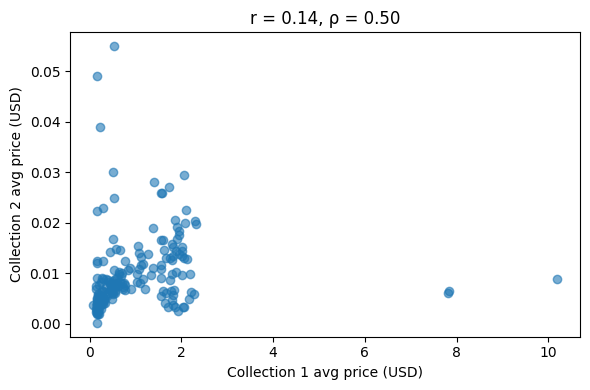

Comparing 3landers and the-scornables
Pearson r = 0.250 (p = 0.238)
Spearman ρ = 0.296 (p = 0.161)


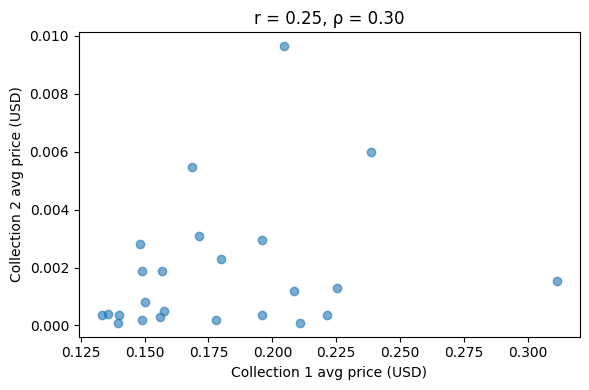

Comparing 3landers and yungapesquad
Pearson r = 0.065 (p = 0.228)
Spearman ρ = 0.660 (p = 4.39e-44)


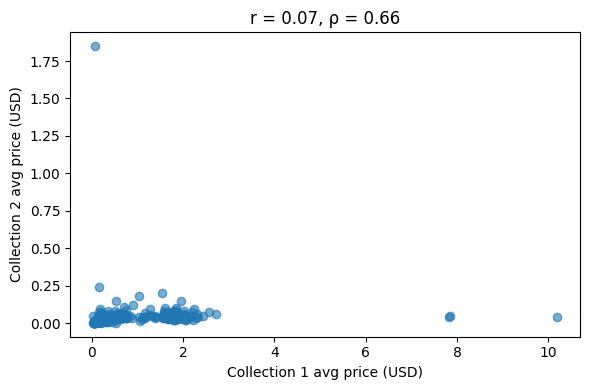

Comparing 3landers and elfooznfts
Pearson r = 0.007 (p = 0.958)
Spearman ρ = 0.229 (p = 0.081)


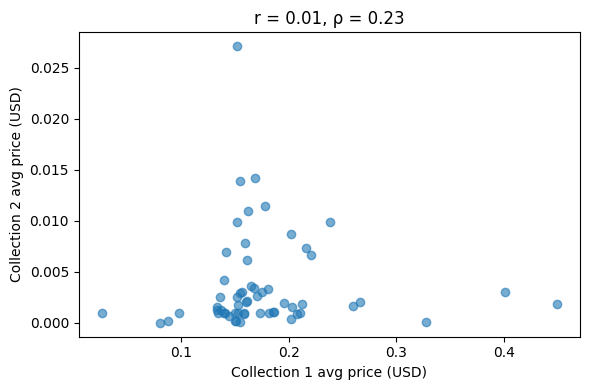

Comparing 3landers and pndnft
Pearson r = 0.677 (p = 0.000386)
Spearman ρ = 0.769 (p = 1.82e-05)


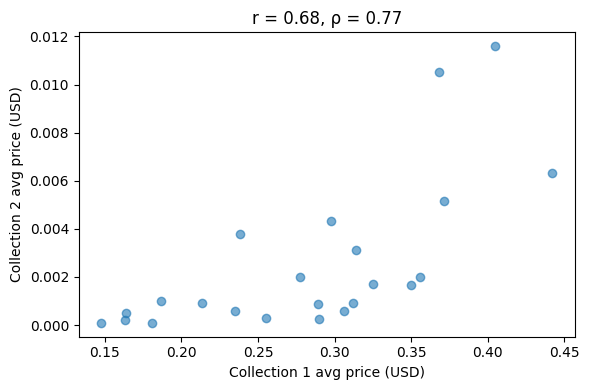

Comparing 3landers and springfieldapesnft
Pearson r = -0.481 (p = 6.66e-05)
Spearman ρ = -0.496 (p = 3.5e-05)


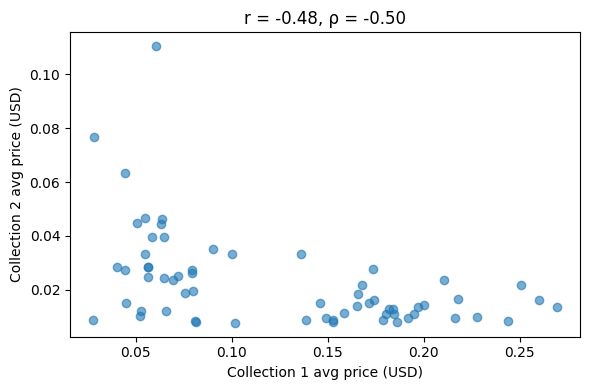

Comparing 3landers and the-chimpsons-pets
Pearson r = 0.093 (p = 0.705)
Spearman ρ = 0.150 (p = 0.54)


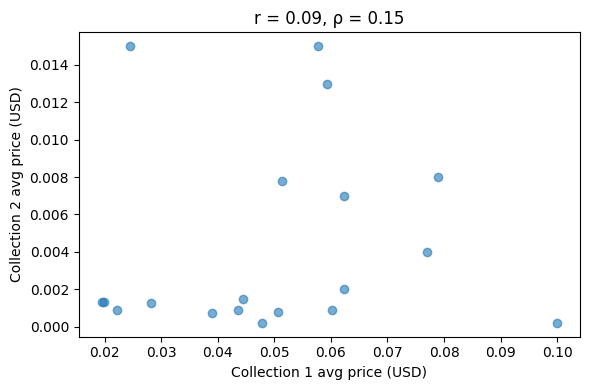

Comparing 3landers and hoodles-official
Pearson r = 0.552 (p = 5.18e-11)
Spearman ρ = 0.664 (p = 1.07e-16)


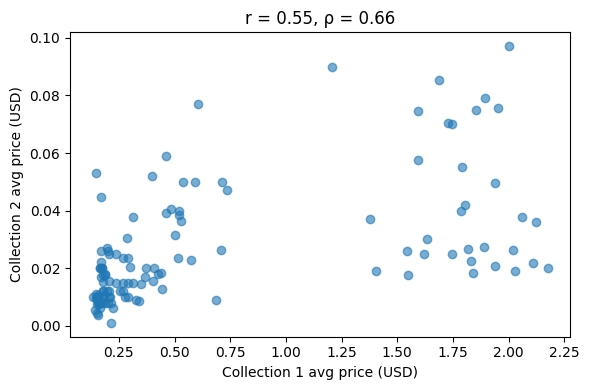

Comparing 3landers and goodmonkeyz
Pearson r = 0.120 (p = 0.41)
Spearman ρ = 0.615 (p = 2.58e-06)


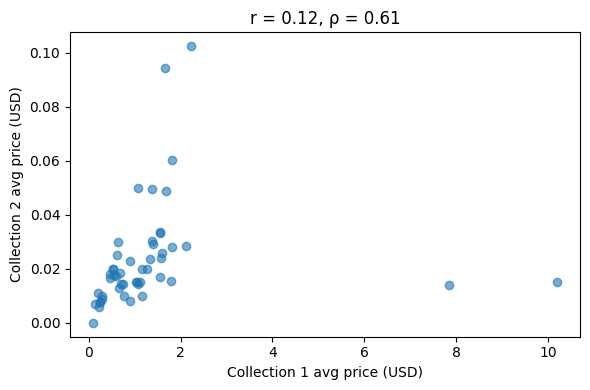

Comparing 3landers and make-it-legal-2
Pearson r = -0.273 (p = 0.346)
Spearman ρ = 0.064 (p = 0.828)


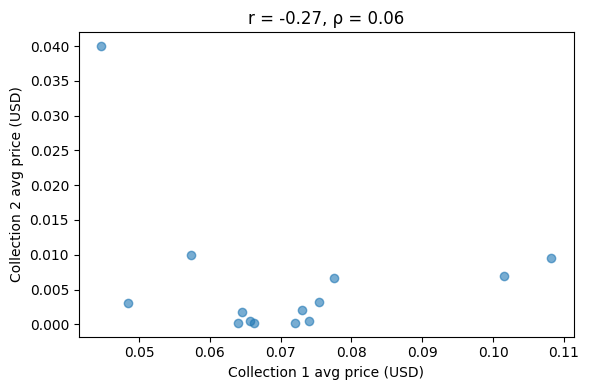

Comparing 3landers and mfn-gutter-punks
Pearson r = 0.022 (p = 0.855)
Spearman ρ = 0.261 (p = 0.0289)


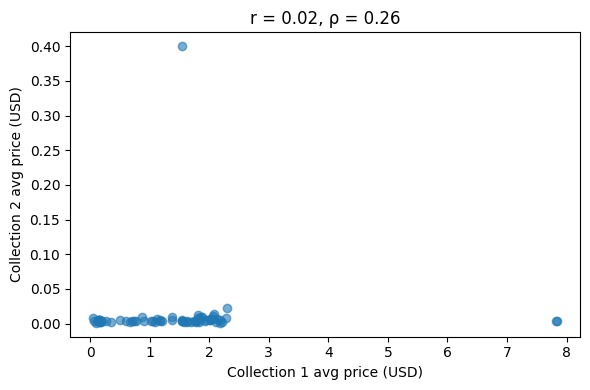

Comparing 3landers and metaflexer
Pearson r = 0.043 (p = 0.926)
Spearman ρ = 0.000 (p = 1)


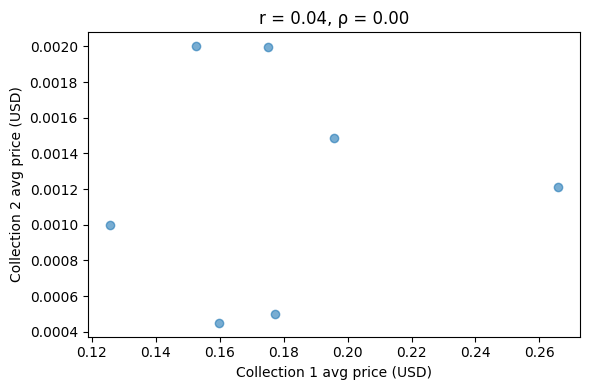

Comparing 3landers and small-graffiti
Pearson r = 0.509 (p = 0.00109)
Spearman ρ = 0.280 (p = 0.0891)


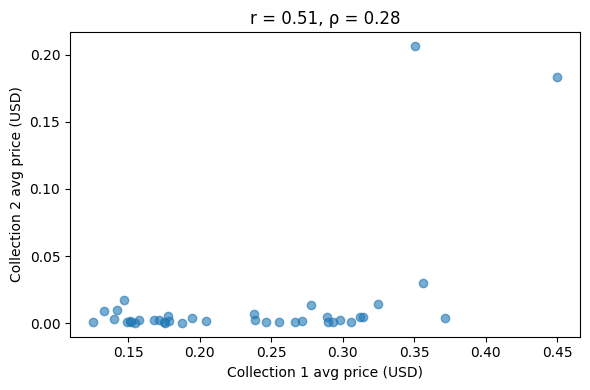

Comparing 3landers and momoape-club
Pearson r = 0.172 (p = 0.745)
Spearman ρ = 0.638 (p = 0.173)


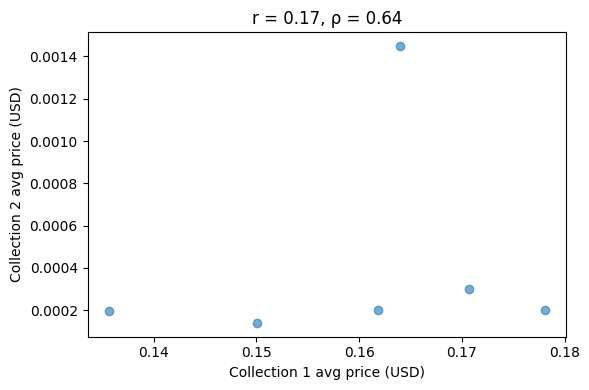

Comparing 3landers and riotgirls
Pearson r = 0.457 (p = 2.47e-09)
Spearman ρ = 0.792 (p = 2.42e-34)


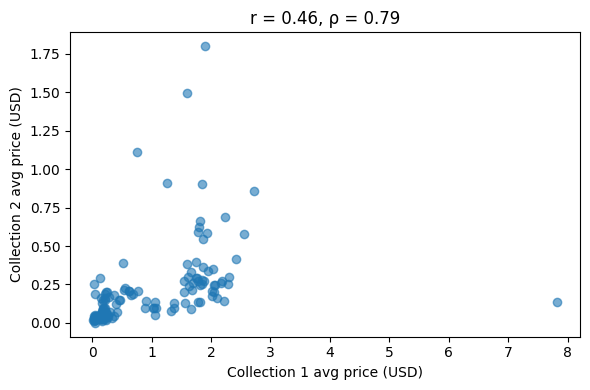

Comparing 3landers and true-plebs
Pearson r = -0.173 (p = 0.361)
Spearman ρ = -0.107 (p = 0.574)


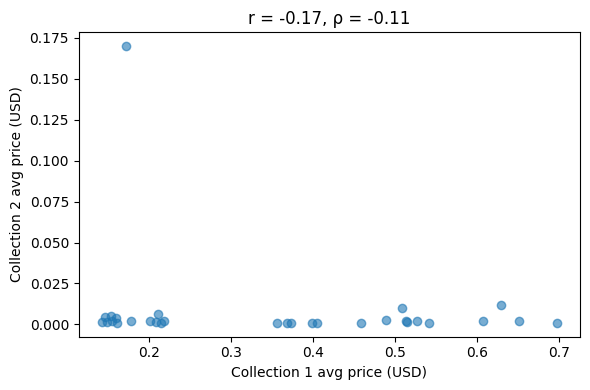

Comparing 3landers and coolapeclubofficial
Pearson r = 0.236 (p = 0.000213)
Spearman ρ = 0.497 (p = 1.85e-16)


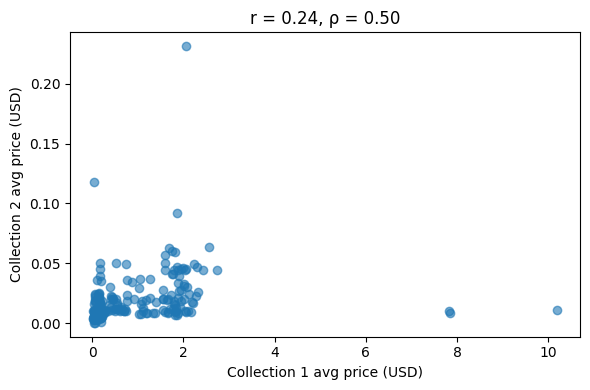

Comparing 3landers and partysheepclub
Pearson r = 0.237 (p = 0.00199)
Spearman ρ = 0.641 (p = 7.96e-21)


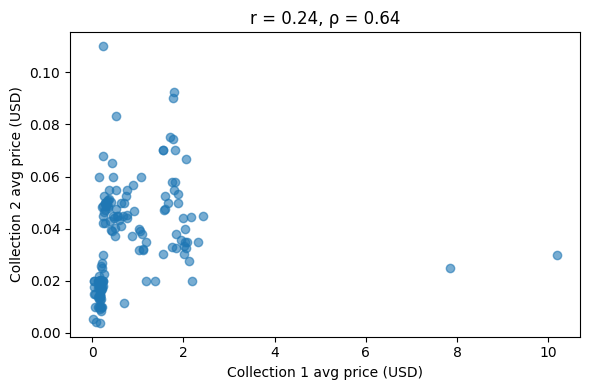

Comparing 3landers and phunkydoodles
Pearson r = 0.329 (p = 0.0537)
Spearman ρ = -0.157 (p = 0.367)


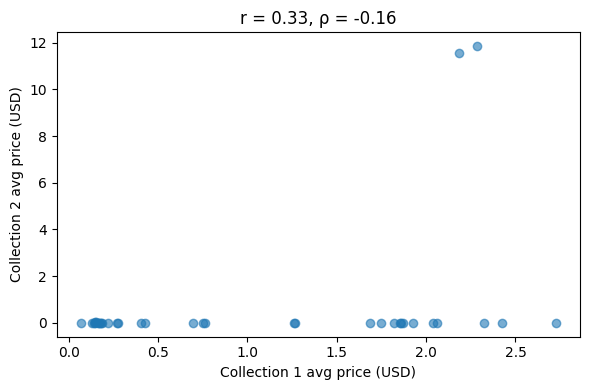

Comparing 3landers and proof-of-monke
Pearson r = 1.000 (p = 1)
Spearman ρ = 1.000 (p = nan)


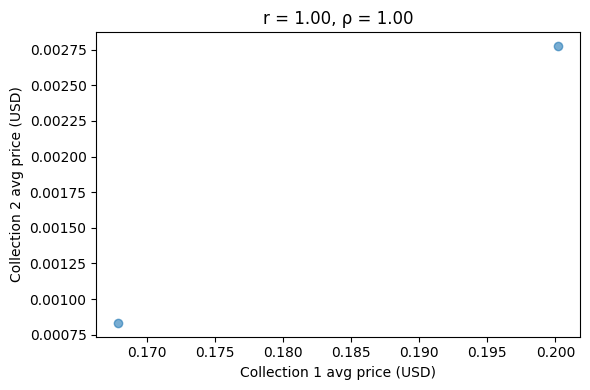

Comparing 3landers and loser-club-official
Pearson r = 0.401 (p = 1.35e-23)
Spearman ρ = 0.885 (p = 2.58e-191)


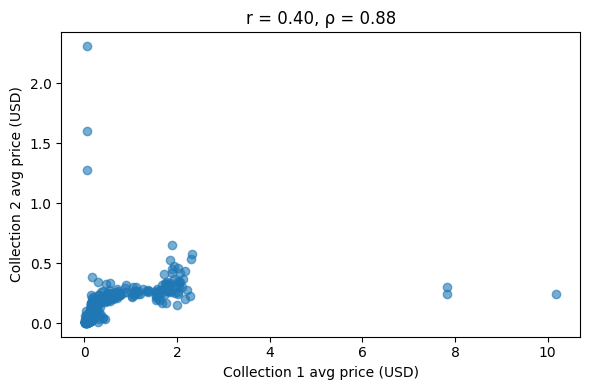

Comparing 3landers and bokinftofficial
Pearson r = 0.638 (p = 7.04e-55)
Spearman ρ = 0.733 (p = 5.89e-80)


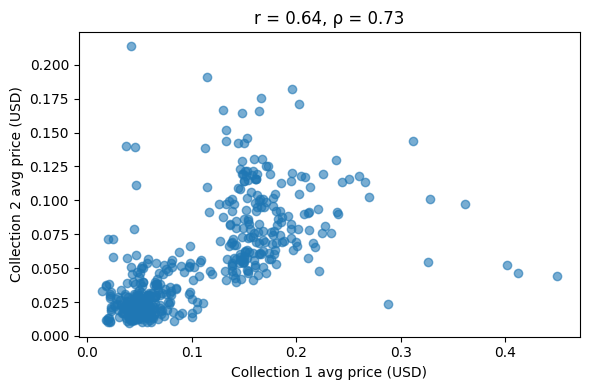

Comparing 3landers and sweetiesnftofficial
Pearson r = 0.089 (p = 0.735)
Spearman ρ = 0.231 (p = 0.373)


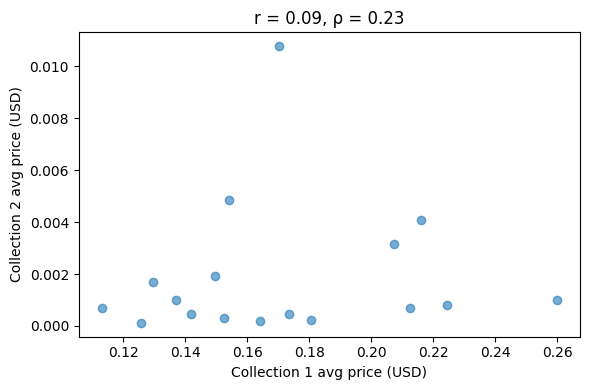

Comparing 3landers and gutter-punks
Pearson r = 0.413 (p = 2.63e-13)
Spearman ρ = 0.689 (p = 6.41e-42)


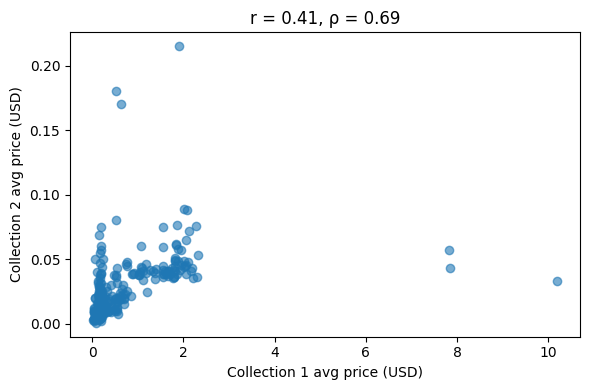

Comparing 3landers and teenrebelapeclub
Pearson r = 0.027 (p = 0.649)
Spearman ρ = 0.489 (p = 3.77e-19)


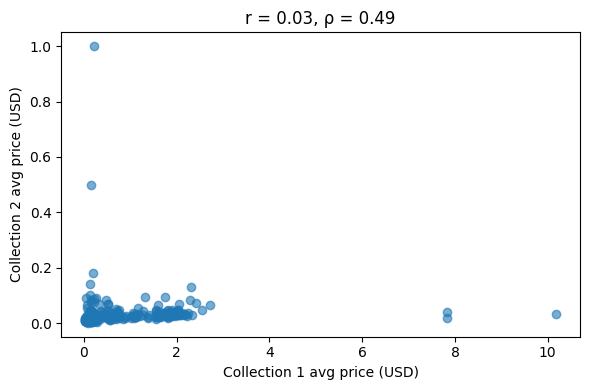

Comparing 3landers and krazykoalas
Pearson r = 0.147 (p = 0.0671)
Spearman ρ = 0.374 (p = 1.61e-06)


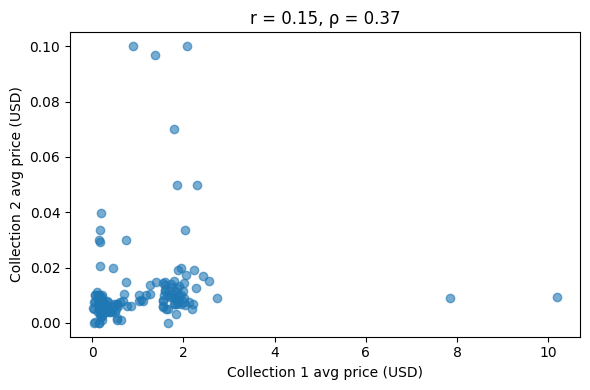

Comparing 3landers and doodles-official
Pearson r = 0.608 (p = 2.81e-71)
Spearman ρ = 0.899 (p = 1.78e-249)


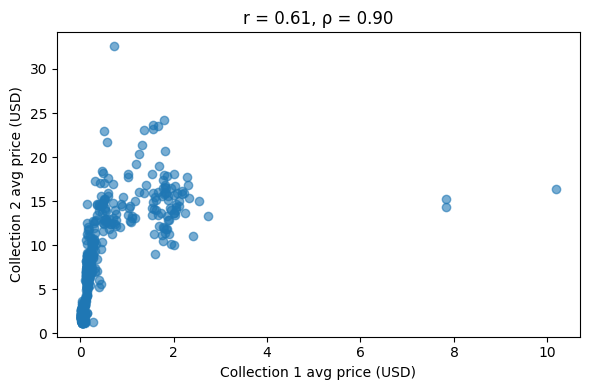

Comparing 3landers and zoofrenz-apefrenz-2-0


ValueError: x and y must have length at least 2.

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# 1. Load or compute your two series: e.g. average daily sales for two collections
#    Suppose you end up with two DataFrames (or Series) indexed by date:
#      df1["price1"], df2["price2"]
slugs1 = cfu.get_top_slugs(cut_off=5, db_name="objective_cf_num")
for slug1 in slugs1:
# Example: if both came from your day_sales_from_db call
    slug2 = cfu.get_look_sims(slug1,remove_ders=True)
    for slug2 in slug2:
        print(f"Comparing {slug1} and {slug2}")
        raw1 = cfu.day_sales_from_db(slug1)
        raw2 = cfu.day_sales_from_db(slug2,look_sim=True)

        # compute daily average price for each
        s1 = (raw1.assign(date=pd.to_datetime(raw1["day"]))
                .groupby("date")["price"].mean())
        s2 = (raw2.assign(date=pd.to_datetime(raw2["day"]))
                .groupby("date")["price"].mean())

        # 2. Combine into one DataFrame
        df = pd.concat([s1.rename("price1"), s2.rename("price2")], axis=1)

        # 3. Clean up: drop any days where one is missing
        df = df.dropna()

        # 4. Compute Pearson and Spearman correlations
        pearson_r, pearson_p = pearsonr(df["price1"], df["price2"])
        spearman_rho, spearman_p = spearmanr(df["price1"], df["price2"])

        print(f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.3g})")
        print(f"Spearman ρ = {spearman_rho:.3f} (p = {spearman_p:.3g})")

        # 5. (Optional) Scatter‐plot
        plt.figure(figsize=(6,4))
        plt.scatter(df["price1"], df["price2"], alpha=0.6)
        plt.xlabel("Collection 1 avg price (USD)")
        plt.ylabel("Collection 2 avg price (USD)")
        plt.title(f"r = {pearson_r:.2f}, ρ = {spearman_rho:.2f}")
        plt.tight_layout()
        plt.show()